In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
a, b = 1, 10
n, N = 7, 500
x = np.linspace(a, b, n)
X = np.linspace(a, b, N)

In [21]:
f = lambda x: np.cos(x)*(1/x)
df = lambda x: -np.sin(x)*(1/x) - np.cos(x)*(1/x**2)

y = f(x)
Y = f(X)
dy = df(x)
dY = df(X)

## Finde den Abschnitt
Indem wir alle Stützstellen $x_j$ gleichzeitig mit einem Wert vergleichen, erhalten wir eine Maske, die die Ungleichung elementweise auswertet. 
`np.argmin` gibt uns den Index des **ersten** elements, das den _minimalwert_ erreicht (True > False). 

In [22]:
print(x < 3)
print(np.argmin(x < 3))

[ True  True False False False False False]
2


Dies können wir auch auf einen ganzen Vektor von Vergleichswerten anwenden, indem wir einen Vektor senkrecht machen und auf der resultierenden Matrix entlang einer Achse das erste `False` suchen (mit `argmin`).

In [23]:
j = np.argmin((x <= X[:,None]), axis=1) # findet das erste x grösser als X für jedes X
jl = (j - 1) % n

# Stelle sicher, dass kein wrap-around passiert:
j[j == 0] = n-1
jl[j == 0] = n-1

Nun suchen wir noch $h$ (die Länge des Abschnitts $[x_{j-1}, x_j]$)<br>
Und $t$ (wie weit wir uns zwischen $x_{j-1}$ und $x_j$ befinden, $t\in[0, 1]$)

In [24]:
h = (np.roll(x, -1) - x)
print(h)
t = (X - x[jl]) / h[jl] 

[ 1.5  1.5  1.5  1.5  1.5  1.5 -9. ]


## Interpolation
Die stückweise Lineare Interpolation ist nun einfach eine linearkombination der zwei nächsten $y$, gewichtet nach dem Anteil der Strecke dazwischen. 

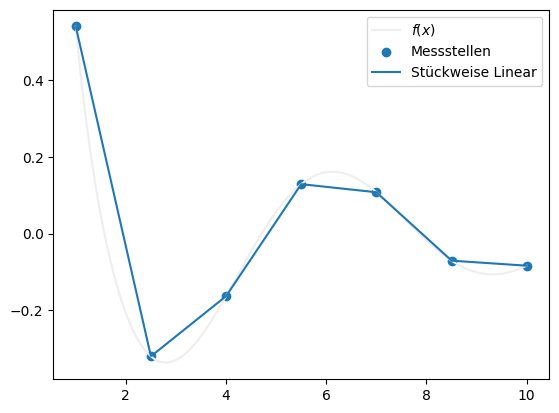

In [25]:
Z = (1 - t) * y[jl] + t * y[j]

plt.plot(X, Y, label=r"$f(x)$", color="#eeeeee")
plt.scatter(x, y, label="Messstellen")
plt.plot(X, Z, label="Stückweise Linear")
plt.legend()

### Kubisch Hermite
Die kubische hermite-interpolation lässt sich nun aus den Funktionen $\phi$ und $\psi$ berechnen (siehe Folien / Skript):

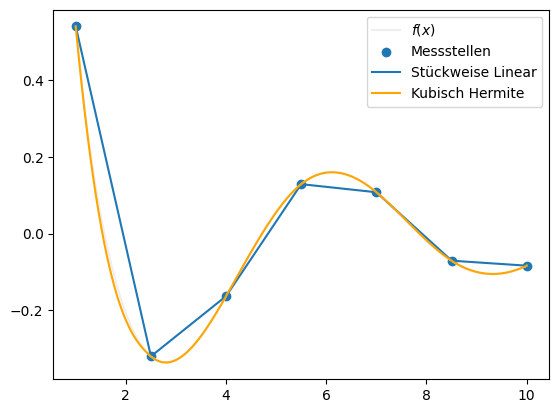

In [26]:
phi = lambda t: 3*t**2 - 2*t**3
psi = lambda t: t**3 - t**2

p = y[jl] * phi(1-t) + y[j] * phi(t)
q = - dy[jl] * h[jl] * psi(1-t) + dy[j] * h[jl] * psi(t)

Z_herm = p + q

plt.plot(X, Y, label=r"$f(x)$", color="#eeeeee")
plt.scatter(x, y, label="Messstellen")
plt.plot(X, Z, label="Stückweise Linear")
plt.plot(X, Z_herm, label="Kubisch Hermite", color="orange")
plt.legend()

Wie man sieht, ist diese zwar viel glatter, hält sich aber nur lokal an den Auswertungsstellen wirklich an den Messwert. Bei dichteren Messwerten ist sie allerdings schon relativ nah. 